# Script to analyze LULC measurement series

[J. Eduardo Vera-Valdés](https://everval.github.io) [](https://orcid.org/0000-0002-0337-8055) (Aalborg University, CoRE)

## Load packages and set up the environment.

In [1]:
#| warning: false
#| message: false
#| output: false
cd(@__DIR__)
using Pkg
Pkg.activate(pwd())

using CSV
using DataFrames
using Plots
using Statistics
include("estimation_functions.jl")

dataframe_to_markdown_table (generic function with 1 method)

## Load the dataset

The data has been downloaded from the Global Carbon Budget 2025 dataset and slightly preprocessed to have the columns of interest in a single CSV file. We will load this data and verify that it has been loaded correctly by showing the last 5 rows of the first 5 columns.

In [1]:
data_path = joinpath(@__DIR__, "..", "data", "Data_GCB_2025_cols.csv")
df = CSV.read(data_path, DataFrame)

last(df[:, 1:5], 5)  # Show the last 5 rows to verify the data is loaded correctly

## Build regression dataset

Load the LULC measurement series and compute the cross-series mean for each year.

In [1]:
# --- LULC: cross-series mean ---
lulc_path = joinpath(@__DIR__, "..", "results", "LULC_measurements_extracted_and_derived.csv")
df_lulc = CSV.read(lulc_path, DataFrame)

# All columns except `year` are LULC series; take their row-wise mean
lulc_series_cols = names(df_lulc, Not(:year))
df_lulc[!, :lulc_mean] = [mean(skipmissing(row)) for row in eachrow(df_lulc[:, lulc_series_cols])]

# GCB-only LULC mean based on BLUE, OSCAR, LUCE
gcb3_cols = ["BLUE", "OSCAR", "LUCE"]
missing_gcb3 = setdiff(gcb3_cols, names(df_lulc))
if !isempty(missing_gcb3)
  error("Missing required GCB LULC columns: $(missing_gcb3)")
end
df_lulc[!, :lulc_mean_gcb3] = [mean(skipmissing(row)) for row in eachrow(df_lulc[:, gcb3_cols])]

df_lulc_mean = select(df_lulc, :year, :lulc_mean)
df_lulc_gcb3_mean = select(df_lulc, :year, :lulc_mean_gcb3)

# --- VAI / ENSO ---
vai_path = joinpath(@__DIR__, "..", "data", "Data_vai_enso.csv")
df_vai = CSV.read(vai_path, DataFrame)
rename!(df_vai, :Year => :year)

# --- GCB: Growth and Fossil ---
df_gcb = select(df, "Year" => :year,
                    "atmospheric growth" => :Growth,
                    "fossil emissions excluding carbonation" => :Fossil)

# --- Join all datasets on year ---
df_reg = innerjoin(df_gcb, df_lulc_mean, on = :year)
df_reg = innerjoin(df_reg, df_lulc_gcb3_mean, on = :year)
df_reg = innerjoin(df_reg, df_vai, on = :year)

# Combined emissions regressor
df_reg[!, :Fossil_plus_LULC] = df_reg.Fossil .+ df_reg.lulc_mean
df_reg[!, :Fossil_plus_LULC_gcb3] = df_reg.Fossil .+ df_reg.lulc_mean_gcb3

last(df_reg, 5)

## OLS regression: Growth ~ Fossil+LULC + VAI + ENSO

In [1]:
Y = Vector{Float64}(df_reg.Growth)
X = hcat(ones(nrow(df_reg)), df_reg.Fossil_plus_LULC, df_reg.VAI, df_reg.ENSO)
X_gcb3 = hcat(ones(nrow(df_reg)), df_reg.Fossil_plus_LULC_gcb3, df_reg.VAI, df_reg.ENSO)

ols = robust_est(Y, X; verbose = true)
ols_gcb3 = robust_est(Y, X_gcb3; verbose = true)

Estimated coefficients: [1.0710154014152704, 0.36430130512028447, -17.386854801416995, 1.054166752269972]
Standard errors: [0.340528751592796, 0.03841042826404604, 3.0813149292312816, 0.13168241615707743]
HAC Standard errors: [0.2856676048242057, 0.03335422089438677, 2.6759753876467833, 0.11806760483916445]
t-statistics: [3.145154106388026, 9.484437471406368, -5.642673728827394, 8.005372190410819]
HAC t-statistics: [3.749166455448641, 10.92219501315329, -6.497389655256419, 8.928501206626427]
p-values: [0.0016599936247414515, 0.0, 1.6742945030401302e-8, 1.1102230246251565e-15]
HAC p-values: [0.00017742329839443016, 0.0, 8.17255152441021e-11, 0.0]
Residual sum of squares: 25.356259589209856
σ²: 0.6395091311765794
Estimated coefficients: [0.8975808501660439, 0.3732221270218924, -17.500283859718493, 1.0731468946598979]
Standard errors: [0.360674751233414, 0.03963454114205342, 3.0909538184688334, 0.1315769299361208]
HAC Standard errors: [0.3128444034591886, 0.03555155918257692, 2.8278697854

(β = [0.8975808501660439, 0.3732221270218924, -17.500283859718493, 1.0731468946598979], σ² = 0.6422249282833338, stderr = [0.360674751233414, 0.03963454114205342, 3.0909538184688334, 0.1315769299361208], stderr_hac = [0.3128444034591886, 0.03555155918257692, 2.8278697854257495, 0.11923056342591859], t_stat = [2.4886157045830086, 9.416587558923261, -5.661774613115253, 8.156041451802373], t_stat_hac = [2.8690967146648534, 10.49805228246644, -6.188504134777104, 9.00060239442444], pvalues = [0.012824150076187868, 0.0, 1.4981551554882344e-8, 4.440892098500626e-16], pvalues_hac = [0.004116459066259459, 0.0, 6.073781477766715e-10, 0.0], u = [-0.22122917327428215, -0.5858369834053108, -0.3647420194519677, -0.5088542792868047, 0.35613656769220325, 0.4429745034153916, 0.7551949643803693, -0.35674357905042164, -0.5046508512992398, 0.6703920388255873  …  0.2164319652279305, -0.4670174655510486, -0.5004469398479845, 0.6232847730947153, -0.3621209291264158, 0.09691530214530619, 0.6760339234403654, 0

## WLS regression: Growth ~ Fossil+LULC + VAI + ENSO

The weights are $w_t = 1 / (\sigma_\varepsilon^2 + \beta_E^2 \cdot \text{Var}(E_{\text{TOT},t}))$, where $\sigma_\varepsilon^2$ is the OLS residual variance, $\beta_E$ is the OLS slope on $E_{\text{TOT}}$, and $\text{Var}(E_{\text{TOT},t})$ is the cross-series variance of $E_{\text{TOT},t} = \text{FF}_t + \text{LULC}_t^{(j)}$ computed over all LULC measurement series.

In [1]:
# --- Cross-series variance of E_TOT per year ---
# Restrict LULC series to years present in the regression sample
df_lulc_reg = innerjoin(df_lulc[:, Not(:lulc_mean)], select(df_reg, :year), on = :year)

# For each year, compute Var_t(FF + LULC^(j)) across all j
fossil_by_year = Dict(r.year => r.Fossil for r in eachrow(df_reg))
var_etot_by_year = Dict(
  r.year => var(Float64[fossil_by_year[r.year] + r[col] for col in lulc_series_cols])
  for r in eachrow(df_lulc_reg)
)
var_etot = [var_etot_by_year[y] for y in df_reg.year]

var_etot_gcb3_by_year = Dict(
  r.year => var(Float64[fossil_by_year[r.year] + r[col] for col in gcb3_cols])
  for r in eachrow(df_lulc_reg)
)
var_etot_gcb3 = [var_etot_gcb3_by_year[y] for y in df_reg.year]

# --- OLS ingredients needed for weights ---
σ²_ols = ols.σ²                  # residual variance from OLS
β_E    = ols.β[2]                # slope on Fossil+LULC (column 2 of X)

σ²_ols_gcb3 = ols_gcb3.σ²        # residual variance from OLS (GCB-3 mean)
β_E_gcb3    = ols_gcb3.β[2]      # slope on Fossil+LULC_gcb3 (column 2 of X_gcb3)

# --- Weights ---
wts = 1.0 ./ (σ²_ols .+ β_E^2 .* var_etot)
wts_gcb3 = 1.0 ./ (σ²_ols_gcb3 .+ β_E_gcb3^2 .* var_etot_gcb3)

# --- WLS ---
wls = robust_est(Y, X; w = wts, verbose = true)
wls_gcb3 = robust_est(Y, X_gcb3; w = wts_gcb3, verbose = true)

Estimated coefficients: [1.0749701825205114, 0.36411492185680217, -17.423900555883748, 1.0555537640923405]
Standard errors: [0.2783149280560291, 0.03145736458517433, 2.5096831679562244, 0.10751207823466012]
HAC Standard errors: [0.2850535542534174, 0.03336399343636482, 2.670922391880097, 0.11786738179156768]
t-statistics: [3.862423729941296, 11.574870516279912, -6.942669408773621, 9.818001674085837]
HAC t-statistics: [3.77111657258918, 10.913409467942706, -6.523551792015506, 8.955435745225449]
p-values: [0.00011226762101412824, 0.0, 3.8475889141409425e-12, 0.0]
HAC p-values: [0.0001625187259375327, 0.0, 6.86617429579428e-11, 0.0]
Residual sum of squares: 25.35653915226881
σ²: 0.6328680954435815
Estimated coefficients: [0.9016393161339253, 0.3728451235954854, -17.556450753639893, 1.0737699506363312]
Standard errors: [0.2884541859079216, 0.0316675000390761, 2.465115344080627, 0.10492487955250586]
HAC Standard errors: [0.31453244195993574, 0.03572682740549477, 2.838619750260954, 0.1194769

(β = [0.9016393161339253, 0.3728451235954854, -17.556450753639893, 1.0737699506363312], σ² = 0.6358080945115446, stderr = [0.2884541859079216, 0.0316675000390761, 2.465115344080627, 0.10492487955250586], stderr_hac = [0.31453244195993574, 0.03572682740549477, 2.838619750260954, 0.11947693777362994], t_stat = [3.125762634700474, 11.773746684626614, -7.121959139071292, 10.233702008673756], t_stat_hac = [2.866601964857964, 10.435998678632796, -6.18485471751753, 8.987257044290649], pvalues = [0.001773446329663253, 0.0, 1.06403774680075e-12, 0.0], pvalues_hac = [0.004149044791891265, 0.0, 6.215969960976508e-10, 0.0], u = [-0.223230317547078, -0.5878312320171959, -0.36668650726698315, -0.5106369854346862, 0.35842156158207583, 0.44609276574071555, 0.7554990089671072, -0.35825418552125976, -0.505967850315264, 0.6700060036349236  …  0.21617426574253162, -0.4677221342035107, -0.5002246769809391, 0.623905231055387, -0.36215027185770854, 0.09698959737605328, 0.676694753473277, 0.6111552821370161, 

## Linear trend significance for AF with the updated variance formula

We compute airborne fraction as $AF_t = G_t / E_t$, where $E_t = FF_t + \overline{LULC}_t$. The per-year AF variance is computed as

$$\mathrm{Var}(AF_t) = \frac{\mathrm{Var}(G_t)}{E_t^2} + \frac{G_t^2}{E_t^4}\,\mathrm{Var}(E_t) - 2\,\frac{G_t}{E_t^3}\,\beta_E\,\mathrm{Var}(E_t),$$

with $\mathrm{Var}(G_t) = x_t'\,\mathrm{Cov}(A)\,x_t$ from the first-stage growth regression (where $x_t$ is the regressor vector and $\mathrm{Cov}(A)$ is the covariance matrix of coefficient estimates), and $\mathrm{Var}(E_t)$ given by cross-series LULC dispersion.

In [1]:
# Build AF series and its measurement-error variance under the new scheme
analysis_df = copy(df_reg)
analysis_df[!, :E_TOT] = analysis_df.Fossil_plus_LULC
analysis_df[!, :AF] = analysis_df.Growth ./ analysis_df.E_TOT

# Observation-specific Var(G_t) = x_t' * Cov(A) * x_t
cov_A = σ²_ols .* inv(transpose(X) * X)
var_g = [((transpose(X[i, :]) * cov_A * X[i, :])[1]) for i in 1:size(X, 1)]

analysis_df[!, :var_E] = var_etot
analysis_df[!, :AF_var] = var_g ./ (analysis_df.E_TOT .^ 2) .+
              (analysis_df.Growth .^ 2) ./ (analysis_df.E_TOT .^ 4) .* analysis_df.var_E 
analysis_df[!, :AF_var] = max.(analysis_df.AF_var, eps(Float64))

# Same AF construction for GCB-only LULC mean (BLUE, OSCAR, LUCE)
analysis_df_gcb3 = copy(df_reg)
analysis_df_gcb3[!, :E_TOT] = analysis_df_gcb3.Fossil_plus_LULC_gcb3
analysis_df_gcb3[!, :AF] = analysis_df_gcb3.Growth ./ analysis_df_gcb3.E_TOT

cov_A_gcb3 = σ²_ols_gcb3 .* inv(transpose(X_gcb3) * X_gcb3)
var_g_gcb3 = [((transpose(X_gcb3[i, :]) * cov_A_gcb3 * X_gcb3[i, :])[1]) for i in 1:size(X_gcb3, 1)]

analysis_df_gcb3[!, :var_E] = var_etot_gcb3
analysis_df_gcb3[!, :AF_var] = var_g_gcb3 ./ (analysis_df_gcb3.E_TOT .^ 2) .+
                               (analysis_df_gcb3.Growth .^ 2) ./ (analysis_df_gcb3.E_TOT .^ 4) .* analysis_df_gcb3.var_E
analysis_df_gcb3[!, :AF_var] = max.(analysis_df_gcb3.AF_var, eps(Float64))

# Trend regressor
t = analysis_df.year .- minimum(analysis_df.year)
X_trend = hcat(ones(nrow(analysis_df)), t)
t_gcb3 = analysis_df_gcb3.year .- minimum(analysis_df_gcb3.year)
X_trend_gcb3 = hcat(ones(nrow(analysis_df_gcb3)), t_gcb3)

# OLS and WLS trend models
trend_ols = robust_est(analysis_df.AF, X_trend; verbose = true)
trend_wls = robust_est(analysis_df.AF, X_trend; w = 1.0 ./ analysis_df.AF_var, verbose = true)
trend_ols_gcb3 = robust_est(analysis_df_gcb3.AF, X_trend_gcb3; verbose = true)
trend_wls_gcb3 = robust_est(analysis_df_gcb3.AF, X_trend_gcb3; w = 1.0 ./ analysis_df_gcb3.AF_var, verbose = true)

Estimated coefficients: [0.4019380374160654, 0.0011722969671288848]
Standard errors: [0.029842511650800034, 0.0007921705103149584]
HAC Standard errors: [0.028272677588845604, 0.0006434181956464673]
t-statistics: [13.468639708323277, 1.4798543392669241]
HAC t-statistics: [14.216482897772712, 1.8219829265957148]
p-values: [0.0, 0.1389121234252435]
HAC p-values: [0.0, 0.06845757628848226]
Residual sum of squares: 0.9619847006289137
σ²: 0.12260102343507079
Estimated coefficients: [0.3672860789321205, 0.001382090617620008]
Standard errors: [0.0012425690312758266, 2.840523755694081e-5]
HAC Standard errors: [0.02867987674782308, 0.0006238006616214669]
t-statistics: [295.5860557340657, 48.656189368227786]
HAC t-statistics: [12.806403673265402, 2.215596588223378]
p-values: [0.0, 0.0]
HAC p-values: [0.0, 0.026719142736391532]
Residual sum of squares: 1.014169982319478
σ²: 0.10182996533541544
Estimated coefficients: [0.3714095385656445, 0.0015814220456534644]
Standard errors: [0.0290387931020038,

(β = [0.3688738718510959, 0.0013822020038992047], σ² = 0.09704909283027217, stderr = [0.0007767285159741475, 1.7424753244582116e-5], stderr_hac = [0.0325096230100597, 0.0006910203737675144], t_stat = [474.90708048547225, 79.32405036088377], t_stat_hac = [11.346605641565036, 2.0002333597825728], pvalues = [0.0, 0.0], pvalues_hac = [0.0, 0.04547507113560867], u = [0.05687801668192993, -0.04518165908461841, -0.015512183352578868, -0.11492496574180594, -0.11680085756607872, -0.15768490508991156, 0.10658951087610291, 0.10292892354364963, -0.12315676454157581, 0.019286929644458883  …  0.10143269541449579, 0.09445903939850064, -0.045620083855352656, -0.003485804187325192, 0.01171805997505776, 0.0038489400158458476, -0.010389893799955086, -0.03477043978570604, 0.033153187711003895, 0.21347768335241285], Yfit = [0.3688738718510959, 0.3702560738549951, 0.3716382758588943, 0.3730204778627935, 0.3744026798666927, 0.3757848818705919, 0.3771670838744911, 0.3785492858783903, 0.37993148788228953, 0.38


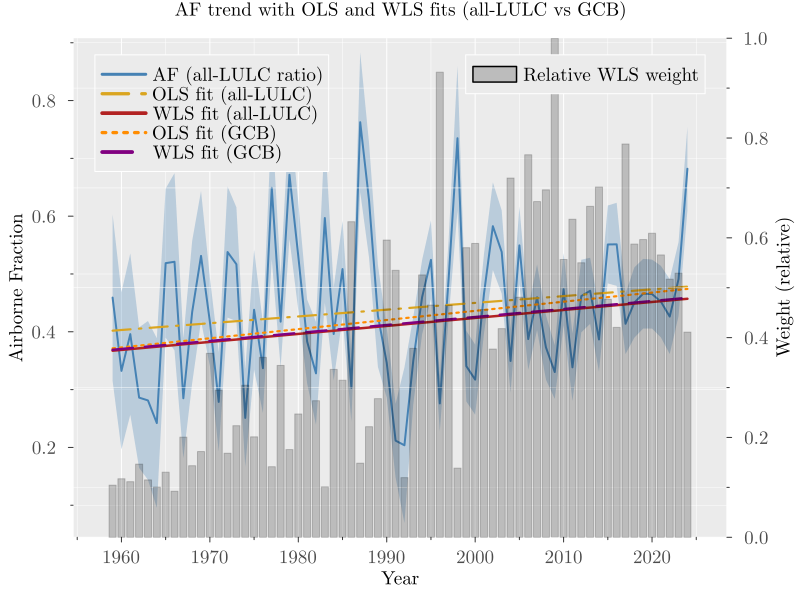

In [1]:
using Plots.PlotMeasures

analysis_df.AF_ols_trend = trend_ols.Yfit
analysis_df.AF_wls_trend = trend_wls.Yfit
analysis_df_gcb3.AF_ols_trend = trend_ols_gcb3.Yfit
analysis_df_gcb3.AF_wls_trend = trend_wls_gcb3.Yfit

w_rel = (1 ./ analysis_df.AF_var) ./ maximum(1 ./ analysis_df.AF_var)
af_sd = sqrt.(analysis_df.AF_var)

p_trend = plot(
  analysis_df.year,
  analysis_df.AF;
  color = :steelblue,
  linewidth = 2.0,
  label = "AF (all-LULC ratio)",
  ribbon = 1.96 .* af_sd,
  fillalpha = 0.3,
  title = "AF trend with OLS and WLS fits (all-LULC vs GCB)",
  xlabel = "Year",
  ylabel = "Airborne Fraction",
  size = (800, 600),
  margin = 3mm,
)
plot!(
  p_trend,
  analysis_df.year,
  analysis_df.AF_ols_trend;
  color = :goldenrod,
  linewidth = 2.2,
  linestyle = :dashdot,
  label = "OLS fit (all-LULC)",
)
plot!(
  p_trend,
  analysis_df.year,
  analysis_df.AF_wls_trend;
  color = :firebrick,
  linewidth = 2.5,
  linestyle = :solid,
  label = "WLS fit (all-LULC)",
)
plot!(
  p_trend,
  analysis_df_gcb3.year,
  analysis_df_gcb3.AF_ols_trend;
  color = :darkorange,
  linewidth = 2.2,
  linestyle = :dot,
  label = "OLS fit (GCB)",
)
plot!(
  p_trend,
  analysis_df_gcb3.year,
  analysis_df_gcb3.AF_wls_trend;
  color = :purple,
  linewidth = 2.5,
  linestyle = :dash,
  label = "WLS fit (GCB)",
  legend = :topleft,
)
p2_trend = twinx()
bar!(
  p2_trend,
  analysis_df.year,
  w_rel;
  bar_width = 0.8,
  color = :black,
  alpha = 0.2,
  label = "Relative WLS weight",
  ylabel = "Weight (relative)",
  legend = :topright,
  grid=false
)
p_trend

In [1]:
savefig(p_trend, joinpath(@__DIR__, "..", "figures", "AF_trends_WLS_growth.png"))
savefig(p_trend, joinpath(@__DIR__, "..", "figures", "AF_trends_WLS_growth.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/AF_trends_WLS_growth.pdf"

In [1]:
#| results: asis
trend_idx = 2

trend_significance = DataFrame(
  Metric = ["Estimate", "Std. error", "p-value", "R-squared"],
  OLS_all = [
    trend_ols.β[trend_idx],
    trend_ols.stderr[trend_idx],
    trend_ols.pvalues[trend_idx],
    trend_ols.rsquared,
  ],
  WLS_all = [
    trend_wls.β[trend_idx],
    trend_wls.stderr[trend_idx],
    trend_wls.pvalues[trend_idx],
    trend_wls.rsquared,
  ],
  OLS_gcb3 = [
    trend_ols_gcb3.β[trend_idx],
    trend_ols_gcb3.stderr[trend_idx],
    trend_ols_gcb3.pvalues[trend_idx],
    trend_ols_gcb3.rsquared,
  ],
  WLS_gcb3 = [
    trend_wls_gcb3.β[trend_idx],
    trend_wls_gcb3.stderr[trend_idx],
    trend_wls_gcb3.pvalues[trend_idx],
    trend_wls_gcb3.rsquared,
  ],
)

fmt_num(x) = string(round(x; digits = 6))
header = "| Trend significance | OLS (all-LULC mean) | WLS (all-LULC mean) | OLS (GCB) | WLS (GCB) |"
sep = "|---|---:|---:|---:|---:|"
rows = ["| $(r.Metric) | $(fmt_num(r.OLS_all)) | $(fmt_num(r.WLS_all)) | $(fmt_num(r.OLS_gcb3)) | $(fmt_num(r.WLS_gcb3)) |" for r in eachrow(trend_significance)]

table_md = join([header, sep, rows...], "\n") * "\n"
println(table_md)

table_out_path = joinpath(@__DIR__, "..", "results", "af_growth_wls_trend_full_sample.md")
open(table_out_path, "w") do io
  write(io, table_md)
end

println("Saved markdown table to: $(table_out_path)")

| Trend significance | OLS (all-LULC mean) | WLS (all-LULC mean) | OLS (GCB) | WLS (GCB) |
|---|---:|---:|---:|---:|
| Estimate | 0.001172 | 0.001382 | 0.001581 | 0.001382 |
| Std. error | 0.000792 | 2.8e-5 | 0.000771 | 1.7e-5 |
| p-value | 0.138912 | 0.0 | 0.040212 | 0.0 |
| R-squared | 0.033086 | 0.048024 | 0.061706 | 0.044828 |

Saved markdown table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/af_growth_wls_trend_full_sample.md

## Trend significance without the last observation

In [1]:
analysis_sub = analysis_df[1:end-1, :]
analysis_sub_gcb3 = analysis_df_gcb3[1:end-1, :]
t_sub = analysis_sub.year .- minimum(analysis_sub.year)
X_trend_sub = hcat(ones(nrow(analysis_sub)), t_sub)
t_sub_gcb3 = analysis_sub_gcb3.year .- minimum(analysis_sub_gcb3.year)
X_trend_sub_gcb3 = hcat(ones(nrow(analysis_sub_gcb3)), t_sub_gcb3)

trend_ols_sub = robust_est(analysis_sub.AF, X_trend_sub; verbose = true)
trend_wls_sub = robust_est(analysis_sub.AF, X_trend_sub; w = 1.0 ./ analysis_sub.AF_var, verbose = true)
trend_ols_sub_gcb3 = robust_est(analysis_sub_gcb3.AF, X_trend_sub_gcb3; verbose = true)
trend_wls_sub_gcb3 = robust_est(analysis_sub_gcb3.AF, X_trend_sub_gcb3; w = 1.0 ./ analysis_sub_gcb3.AF_var, verbose = true)

Estimated coefficients: [0.4082124728254742, 0.0008781828073128439]
Standard errors: [0.029599261633365525, 0.0007979426166749853]
HAC Standard errors: [0.02793809320052781, 0.0005998854689298245]
t-statistics: [13.791305941406323, 1.100558848419725]
HAC t-statistics: [14.61132189285424, 1.463917452242163]
p-values: [0.0, 0.2710887040418912]
HAC p-values: [0.0, 0.14321650427859556]
Residual sum of squares: 0.9177827499729048
σ²: 0.12069788796122355
Estimated coefficients: [0.37691868668503786, 0.0010535517943111169]
Standard errors: [0.0012110406689048983, 2.795177633062354e-5]
HAC Standard errors: [0.026565680852394212, 0.0005293303167690677]
t-statistics: [311.23536670809926, 37.69176534075445]
HAC t-statistics: [14.188180938380443, 1.9903484855010725]
p-values: [0.0, 0.0]
HAC p-values: [0.0, 0.04655256041125155]
Residual sum of squares: 0.9613580694033772
σ²: 0.09845774733986008
Estimated coefficients: [0.3775016220709932, 0.001295855631340241]
Standard errors: [0.028805128197492317

(β = [0.38010898276127725, 0.0010298328099626517], σ² = 0.09382465982848719, stderr = [0.0007582107710868678, 1.7163965024541405e-5], stderr_hac = [0.02947855030434996, 0.0005779932369964862], t_stat = [501.32363882987937, 59.99970336050992], t_stat_hac = [12.894425907544951, 1.781738511879703], pvalues = [0.0, 0.0], pvalues_hac = [0.0, 0.07479188349136101], u = [0.045642905771748565, -0.05606440080086322, -0.02604255587488713, -0.12510296907017765, -0.12662649170051388, -0.16715817003041017, 0.09746861512954086, 0.09416039699102413, -0.13157292190026476, 0.011223141479706489  …  -0.05948617713501392, 0.10993025936476136, 0.10330897254270277, -0.03641778151721392, 0.006068867344750095, 0.0216251007010696, 0.014108349935794184, 0.00022188531392980382, -0.0238062914778846, 0.04446970521276189], Yfit = [0.38010898276127725, 0.3811388155712399, 0.38216864838120257, 0.38319848119116523, 0.38422831400112784, 0.3852581468110905, 0.38628797962105316, 0.3873178124310158, 0.3883476452409785, 0.3


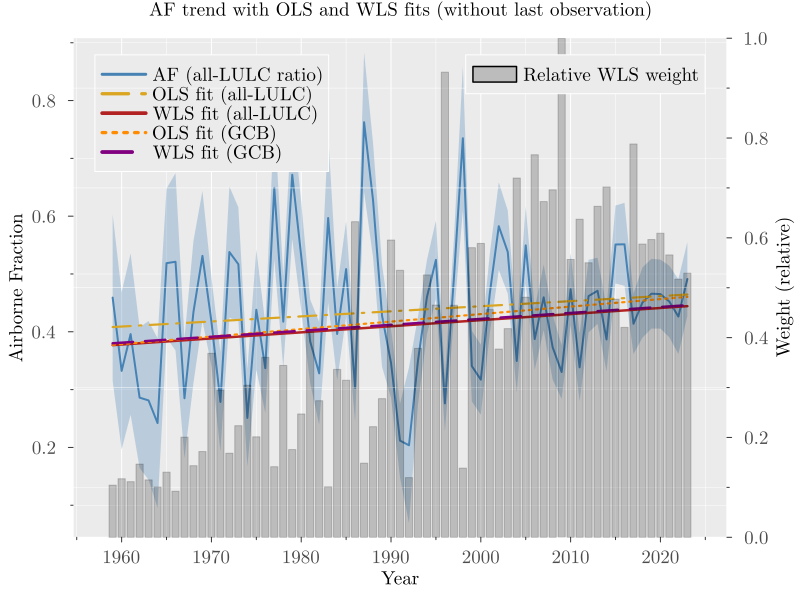

In [1]:
analysis_sub.AF_ols_trend = trend_ols_sub.Yfit
analysis_sub.AF_wls_trend = trend_wls_sub.Yfit
analysis_sub_gcb3.AF_ols_trend = trend_ols_sub_gcb3.Yfit
analysis_sub_gcb3.AF_wls_trend = trend_wls_sub_gcb3.Yfit

w_rel_sub = (1 ./ analysis_sub.AF_var) ./ maximum(1 ./ analysis_sub.AF_var)
af_sd_sub = sqrt.(analysis_sub.AF_var)

p_trend_sub = plot(
  analysis_sub.year,
  analysis_sub.AF;
  color = :steelblue,
  linewidth = 2.0,
  label = "AF (all-LULC ratio)",
  ribbon = 1.96 .* af_sd_sub,
  fillalpha = 0.3,
  title = "AF trend with OLS and WLS fits (without last observation)",
  xlabel = "Year",
  ylabel = "Airborne Fraction",
  size = (800, 600),
  margin = 3mm,
)
plot!(
  p_trend_sub,
  analysis_sub.year,
  analysis_sub.AF_ols_trend;
  color = :goldenrod,
  linewidth = 2.2,
  linestyle = :dashdot,
  label = "OLS fit (all-LULC)",
)
plot!(
  p_trend_sub,
  analysis_sub.year,
  analysis_sub.AF_wls_trend;
  color = :firebrick,
  linewidth = 2.5,
  linestyle = :solid,
  label = "WLS fit (all-LULC)",
)
plot!(
  p_trend_sub,
  analysis_sub_gcb3.year,
  analysis_sub_gcb3.AF_ols_trend;
  color = :darkorange,
  linewidth = 2.2,
  linestyle = :dot,
  label = "OLS fit (GCB)",
)
plot!(
  p_trend_sub,
  analysis_sub_gcb3.year,
  analysis_sub_gcb3.AF_wls_trend;
  color = :purple,
  linewidth = 2.5,
  linestyle = :dash,
  label = "WLS fit (GCB)",
  legend = :topleft,
)
p2_trend_sub = twinx()
bar!(
  p2_trend_sub,
  analysis_sub.year,
  w_rel_sub;
  bar_width = 0.8,
  color = :black,
  alpha = 0.2,
  label = "Relative WLS weight",
  ylabel = "Weight (relative)",
  legend = :topright,
  grid=false
)
p_trend_sub

In [1]:
savefig(p_trend_sub, joinpath(@__DIR__, "..", "figures", "AF_trends_WLS_growth_without_last_observation.png"))
savefig(p_trend_sub, joinpath(@__DIR__, "..", "figures", "AF_trends_WLS_growth_without_last_observation.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/AF_trends_WLS_growth_without_last_observation.pdf"

In [1]:
#| results: asis
trend_significance_sub = DataFrame(
  Metric = ["Estimate", "Std. error", "p-value", "R-squared"],
  OLS_all = [
    trend_ols_sub.β[trend_idx],
    trend_ols_sub.stderr[trend_idx],
    trend_ols_sub.pvalues[trend_idx],
    trend_ols_sub.rsquared,
  ],
  WLS_all = [
    trend_wls_sub.β[trend_idx],
    trend_wls_sub.stderr[trend_idx],
    trend_wls_sub.pvalues[trend_idx],
    trend_wls_sub.rsquared,
  ],
  OLS_gcb3 = [
    trend_ols_sub_gcb3.β[trend_idx],
    trend_ols_sub_gcb3.stderr[trend_idx],
    trend_ols_sub_gcb3.pvalues[trend_idx],
    trend_ols_sub_gcb3.rsquared,
  ],
  WLS_gcb3 = [
    trend_wls_sub_gcb3.β[trend_idx],
    trend_wls_sub_gcb3.stderr[trend_idx],
    trend_wls_sub_gcb3.pvalues[trend_idx],
    trend_wls_sub_gcb3.rsquared,
  ],
)

header_sub = "| Trend significance (without last observation) | OLS (all-LULC mean) | WLS (all-LULC mean) | OLS (GCB) | WLS (GCB) |"
rows_sub = ["| $(r.Metric) | $(fmt_num(r.OLS_all)) | $(fmt_num(r.WLS_all)) | $(fmt_num(r.OLS_gcb3)) | $(fmt_num(r.WLS_gcb3)) |" for r in eachrow(trend_significance_sub)]

table_sub_md = join([header_sub, sep, rows_sub...], "\n") * "\n"
println(table_sub_md)

table_sub_out_path = joinpath(@__DIR__, "..", "results", "af_growth_wls_trend_without_last_observation.md")
open(table_sub_out_path, "w") do io
  write(io, table_sub_md)
end

println("Saved markdown table to: $(table_sub_out_path)")

| Trend significance (without last observation) | OLS (all-LULC mean) | WLS (all-LULC mean) | OLS (GCB) | WLS (GCB) |
|---|---:|---:|---:|---:|
| Estimate | 0.000878 | 0.001054 | 0.001296 | 0.00103 |
| Std. error | 0.000798 | 2.8e-5 | 0.000777 | 1.7e-5 |
| p-value | 0.271089 | 0.0 | 0.095163 | 0.0 |
| R-squared | 0.018863 | 0.029832 | 0.042332 | 0.026554 |

Saved markdown table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/af_growth_wls_trend_without_last_observation.md

### Supplementary table: intercept estimates

In [1]:
#| results: asis
intercept_idx = 1

intercept_table = DataFrame(
  Metric = [
    "Estimate",
    "Std. error",
    "p-value",
    "R-squared",
  ],
  OLS_all = [
    trend_ols.β[intercept_idx],
    trend_ols.stderr[intercept_idx],
    trend_ols.pvalues[intercept_idx],
    trend_ols.rsquared,
  ],
  WLS_all = [
    trend_wls.β[intercept_idx],
    trend_wls.stderr[intercept_idx],
    trend_wls.pvalues[intercept_idx],
    trend_wls.rsquared,
  ],
  OLS_gcb3 = [
    trend_ols_gcb3.β[intercept_idx],
    trend_ols_gcb3.stderr[intercept_idx],
    trend_ols_gcb3.pvalues[intercept_idx],
    trend_ols_gcb3.rsquared,
  ],
  WLS_gcb3 = [
    trend_wls_gcb3.β[intercept_idx],
    trend_wls_gcb3.stderr[intercept_idx],
    trend_wls_gcb3.pvalues[intercept_idx],
    trend_wls_gcb3.rsquared,
  ],
  OLS_all_without_last = [
    trend_ols_sub.β[intercept_idx],
    trend_ols_sub.stderr[intercept_idx],
    trend_ols_sub.pvalues[intercept_idx],
    trend_ols_sub.rsquared,
  ],
  WLS_all_without_last = [
    trend_wls_sub.β[intercept_idx],
    trend_wls_sub.stderr[intercept_idx],
    trend_wls_sub.pvalues[intercept_idx],
    trend_wls_sub.rsquared,
  ],
  OLS_gcb3_without_last = [
    trend_ols_sub_gcb3.β[intercept_idx],
    trend_ols_sub_gcb3.stderr[intercept_idx],
    trend_ols_sub_gcb3.pvalues[intercept_idx],
    trend_ols_sub_gcb3.rsquared,
  ],
  WLS_gcb3_without_last = [
    trend_wls_sub_gcb3.β[intercept_idx],
    trend_wls_sub_gcb3.stderr[intercept_idx],
    trend_wls_sub_gcb3.pvalues[intercept_idx],
    trend_wls_sub_gcb3.rsquared,
  ],
)

header_int = "| Metric | OLS (all-LULC mean) full | WLS (all-LULC mean) full | OLS (GCB) full | WLS (GCB) full | OLS (all-LULC mean) without last obs. | WLS (all-LULC mean) without last obs. | OLS (GCB) without last obs. | WLS (GCB) without last obs. |"
sep_int = "|---|---:|---:|---:|---:|---:|---:|---:|---:|"
rows_int = ["| $(r.Metric) | $(fmt_num(r.OLS_all)) | $(fmt_num(r.WLS_all)) | $(fmt_num(r.OLS_gcb3)) | $(fmt_num(r.WLS_gcb3)) | $(fmt_num(r.OLS_all_without_last)) | $(fmt_num(r.WLS_all_without_last)) | $(fmt_num(r.OLS_gcb3_without_last)) | $(fmt_num(r.WLS_gcb3_without_last)) |" for r in eachrow(intercept_table)]

table_int_md = join([header_int, sep_int, rows_int...], "\n") * "\n"
println(table_int_md)

intercept_out_path = joinpath(@__DIR__, "..", "results", "af_growth_wls_intercept_summary_table.md")
open(intercept_out_path, "w") do io
  write(io, table_int_md)
end

println("Saved markdown table to: $(intercept_out_path)")

| Metric | OLS (all-LULC mean) full | WLS (all-LULC mean) full | OLS (GCB) full | WLS (GCB) full | OLS (all-LULC mean) without last obs. | WLS (all-LULC mean) without last obs. | OLS (GCB) without last obs. | WLS (GCB) without last obs. |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Estimate | 0.401938 | 0.367286 | 0.37141 | 0.368874 | 0.408212 | 0.376919 | 0.377502 | 0.380109 |
| Std. error | 0.029843 | 0.001243 | 0.029039 | 0.000777 | 0.029599 | 0.001211 | 0.028805 | 0.000758 |
| p-value | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
| R-squared | 0.033086 | 0.048024 | 0.061706 | 0.044828 | 0.018863 | 0.029832 | 0.042332 | 0.026554 |

Saved markdown table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/af_growth_wls_intercept_summary_table.md